<a href="https://colab.research.google.com/github/Cado87/Monai_projects/blob/main/Spleen%20segmentation/Spleen_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup
First, we need to install the required libraries: MONAI (with all its dependencies like `pydicom` and `nibabel`), `tqdm` for progress bars, and `matplotlib` for plotting.

In [1]:
# Instalamos las librerías necesarias fijando NumPy para evitar incompatibilidades binarias con MONAI
!pip install -q "monai[all]" "tqdm" "matplotlib" "numpy==1.26.4" --quiet

Next, we'll import the necessary modules from `monai`, `pydicom`, `nibabel`, `matplotlib`, and `numpy`.

In [2]:
import os
import tempfile
import matplotlib.pyplot as plt
import numpy as np

# Verificación de versión de NumPy para evitar el error de importación
try:
    import pydicom
    import nibabel as nib
    from monai.transforms import LoadImage, Orientation, ScaleIntensityRange, Resize, Compose
    from monai.data import decollate_batch
    from monai.visualize import plot_2d_or_3d_image
    from monai.utils import first
    print(f"Importación exitosa. NumPy versión: {np.__version__}")
except ImportError as e:
    print(f"Error de importación: {e}")
    if "numpy" in str(e).lower():
        print("\nSOLUCIÓN: NumPy 2.0 no es compatible con estas versiones de MONAI.")
        print("Por favor, ve a 'Runtime' -> 'Restart session' y ejecuta todo de nuevo para activar el downgrade.")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Importación exitosa. NumPy versión: 1.26.4


## Download Sample NIfTI Dataset
We'll download a small brain MRI dataset (BraTS 2018) from MONAI's public resources to use as real NIfTI data. This involves using `gdown` to download a zipped file and then extracting its contents.

In [3]:
from monai.apps import download_and_extract
import os
import shutil
import tempfile # Import tempfile for creating temporary directory

# Define data_dir at the beginning of the cell
data_dir = tempfile.mkdtemp()

# Define the resource URL for Task09_Spleen.tar
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar"

# Ensure clean extraction by removing existing directory if it exists
extracted_target_dir = os.path.join(data_dir, "Task09_Spleen")
if os.path.exists(extracted_target_dir):
    print(f"Removing existing directory: {extracted_target_dir}")
    shutil.rmtree(extracted_target_dir)

print(f"Downloading and extracting Task09_Spleen dataset to: {data_dir}")
# download_and_extract handles creation of subdirectories
# It will extract to data_dir/Task09_Spleen/
download_and_extract(resource, output_dir=data_dir, file_type="tar")
print("Dataset downloaded and extracted.")

# --- Debugging: Inspect extracted contents ---
print(f"Contents of {data_dir}: {os.listdir(data_dir)}")

# After extraction, Task09_Spleen should exist
if os.path.exists(extracted_target_dir):
    print(f"Contents of {extracted_target_dir}: {os.listdir(extracted_target_dir)}")
    images_tr_dir = os.path.join(extracted_target_dir, "imagesTr")
    if os.path.exists(images_tr_dir):
        # Filter out AppleDouble files (starting with '._')
        actual_nifti_files = [f for f in os.listdir(images_tr_dir) if f.endswith('.nii.gz') and not f.startswith('._')]
        if actual_nifti_files:
            print(f"Actual NIfTI files found in {images_tr_dir}: {actual_nifti_files[:5]}...")
            # Pick the first actual NIfTI file found
            real_nifti_filepath = os.path.join(images_tr_dir, actual_nifti_files[0])

            # Update nifti_filepath to point to a real image from the downloaded dataset
            global nifti_filepath
            nifti_filepath = real_nifti_filepath
            print(f"Updated NIfTI filepath to real data: {nifti_filepath}")
        else:
            print(f"No .nii.gz files found in {images_tr_dir} after filtering. Keeping dummy NIfTI filepath.")
            real_nifti_filepath = None # Indicate it wasn't found
    else:
        print(f"Directory {images_tr_dir} does not exist. Keeping dummy NIfTI filepath.")
        real_nifti_filepath = None
else:
    print(f"Directory {extracted_target_dir} does not exist after download. Keeping dummy NIfTI filepath.")
    real_nifti_filepath = None

# If real_nifti_filepath was not updated, keep the dummy one
if real_nifti_filepath is None:
    print("Keeping the dummy NIfTI filepath for now.")

Task09_Spleen.tar: 1.50GB [01:45, 15.3MB/s]                            

2026-06-13 11:11:46,150 - INFO - Downloaded: /tmp/tmpe5l3mj2j/Task09_Spleen.tar
2026-06-13 11:11:46,151 - INFO - Expected md5 is None, skip md5 check for file /tmp/tmpe5l3mj2j/Task09_Spleen.tar.
2026-06-13 11:11:46,151 - INFO - Writing into directory: /tmp/tmp7c48tte3.


Dataset downloaded and extracted.
Contents of /tmp/tmp7c48tte3: ['._Task09_Spleen', 'Task09_Spleen']
Contents of /tmp/tmp7c48tte3/Task09_Spleen: ['._labelsTr', 'dataset.json', 'imagesTr', '._imagesTs', '._imagesTr', 'imagesTs', '._dataset.json', 'labelsTr']
Actual NIfTI files found in /tmp/tmp7c48tte3/Task09_Spleen/imagesTr: ['spleen_63.nii.gz', 'spleen_2.nii.gz', 'spleen_10.nii.gz', 'spleen_31.nii.gz', 'spleen_47.nii.gz']...
Updated NIfTI filepath to real data: /tmp/tmp7c48tte3/Task09_Spleen/imagesTr/spleen_63.nii.gz


## NIfTI File Visualization
We'll use MONAI's `LoadImage` to load the NIfTI file and then `matplotlib` and `plot_2d_or_3d_image` for visualization.

NIfTI image shape: torch.Size([512, 512, 60])


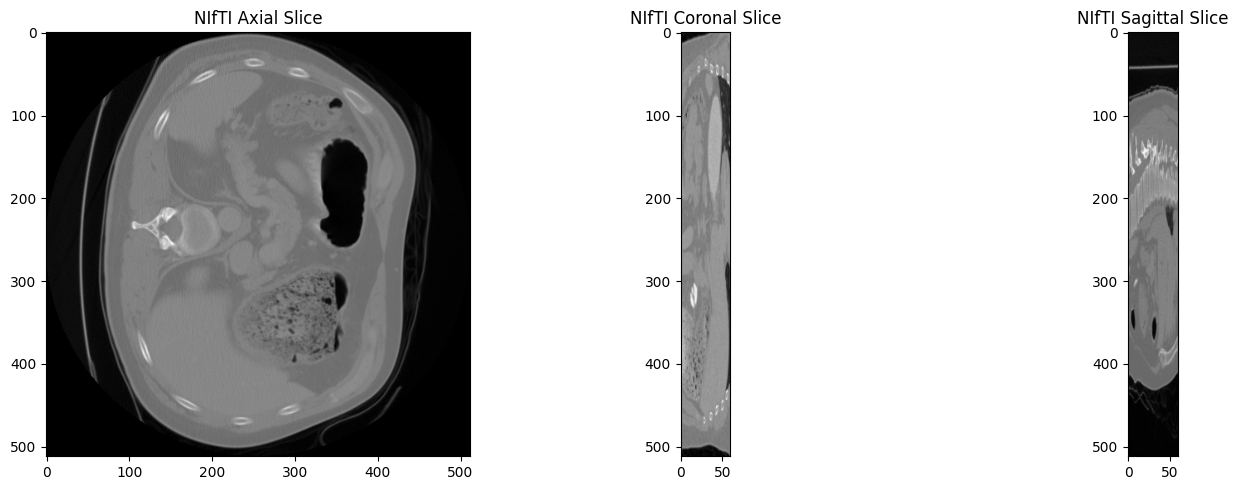

In [4]:
# Load NIfTI file
nifti_loader = LoadImage(image_only=True)
nifti_image = nifti_loader(nifti_filepath)
print(f"NIfTI image shape: {nifti_image.shape}")

# Visualize NIfTI image (middle slice) using matplotlib for axial, coronal, and sagittal views
plt.figure("NIfTI Visualization", (15, 5))
plt.subplot(1, 3, 1)
plt.title("NIfTI Axial Slice")
plt.imshow(nifti_image[..., nifti_image.shape[-1] // 2], cmap="gray")
plt.subplot(1, 3, 2)
plt.title("NIfTI Coronal Slice")
plt.imshow(nifti_image[:, nifti_image.shape[1] // 2, :], cmap="gray")
plt.subplot(1, 3, 3)
plt.title("NIfTI Sagittal Slice")
plt.imshow(nifti_image[nifti_image.shape[0] // 2, :, :], cmap="gray")
plt.tight_layout()
plt.show()

### 1. Segmentation Dataset Preparation
We will configure the data dictionaries and the necessary transforms for training.

In [5]:
from monai.transforms import (LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd, ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld, RandFlipd, RandRotate90d, RandGaussianNoised, DivisiblePadd, Compose, Resized)
from monai.data import CacheDataset, DataLoader, pad_list_data_collate
import glob
from monai.utils import first
import os
import tempfile

try:
    if 'data_dir' not in globals():
        base_temp = tempfile.gettempdir()
        candidates = [os.path.join(base_temp, d) for d in os.listdir(base_temp) if "tmp" in d and os.path.isdir(os.path.join(base_temp, d, "Task09_Spleen"))]
        data_dir = candidates[0] if candidates else base_temp
except:
    data_dir = tempfile.gettempdir()

extracted_target_dir = os.path.join(data_dir, "Task09_Spleen")
images_tr_dir = os.path.join(extracted_target_dir, "imagesTr")
labels_tr_dir = os.path.join(extracted_target_dir, "labelsTr")

train_images = sorted(glob.glob(os.path.join(images_tr_dir, "*.nii.gz")))
train_labels = sorted(glob.glob(os.path.join(labels_tr_dir, "*.nii.gz")))
data_dicts = [{"image": image, "label": label} for image, label in zip(train_images, train_labels)]

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 128),
        pos=3, neg=1, num_samples=4,
        image_key="image", image_threshold=0,
        allow_smaller=True,
    ),
    # FIX: Ensure all crops are exactly 128^3 even if allow_smaller was triggered
    DivisiblePadd(keys=["image", "label"], k=128),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.5),
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=[0, 2]),
    RandGaussianNoised(keys=["image"], prob=0.1),
])

train_ds = CacheDataset(data=data_dicts, transform=train_transforms, cache_rate=1.0, num_workers=4)
# FIX: Added pad_list_data_collate to handle potential shape mismatches during batching
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0, collate_fn=pad_list_data_collate)

check_data = first(train_loader)
print(f"Batch Image shape: {check_data['image'].shape}")

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
Loading dataset: 100%|██████████| 41/41 [00:33<00:00,  1.21it/s]


Batch Image shape: torch.Size([8, 1, 128, 128, 128])


### 2. Image and Mask Visualization
We will verify that the segmentation mask matches the spleen's anatomy in the original image.

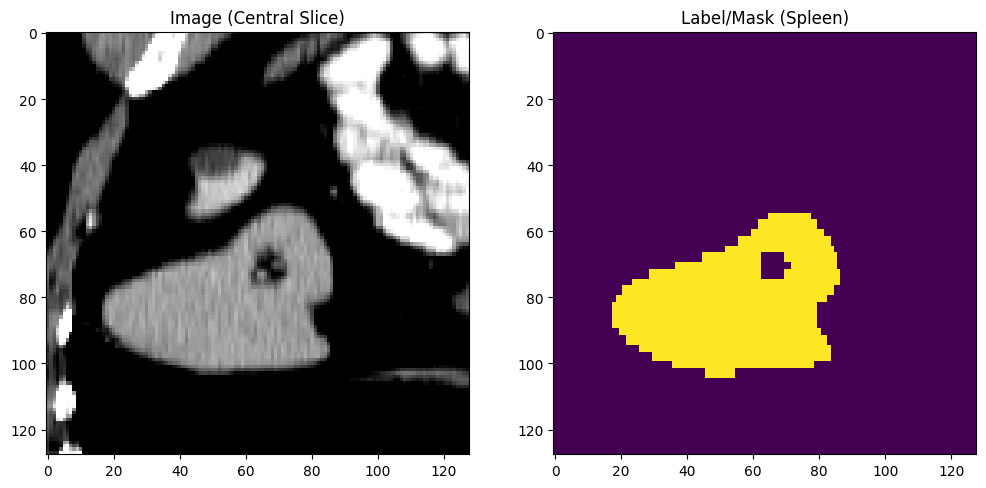

In [6]:
# Extract a sample from the check_data batch
# check_data['image'] has shape [Batch, Channel, H, W, D]
image = check_data["image"][0, 0]
label = check_data["label"][0, 0]

plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Image (Central Slice)")
plt.imshow(image[:, :, image.shape[2] // 2], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Label/Mask (Spleen)")
plt.imshow(label[:, :, label.shape[2] // 2])
plt.show()

### 3. Define Model, Loss, and Optimizer
We will use a standard UNet architecture from MONAI, optimized for 3D segmentation, along with Dice Loss.

In [7]:
import torch
from monai.networks.nets import UNet
from monai.losses import DiceLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the UNet architecture
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2, # Spleen and Background
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

# Define Loss function and Optimizer
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

print(f"Model initialized on device: {device}")

Model initialized on device: cuda


### 5. Advanced Training: Early Stopping and LR Scheduling
To handle the plateau you observed, we can use `torch.optim.lr_scheduler` and a custom EarlyStopping class.

In [8]:
# from torch.optim.lr_scheduler import ReduceLROnPlateau

# # Initialize scheduler (removed deprecated 'verbose' argument)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

# # Simple Early Stopping logic
# max_epochs = 300
# patience = 30
# counter = 0
# best_loss = float('inf')

# print("Re-starting training with Scheduler and Early Stopping...")

# # Note: This is a continuation. If you want to start fresh, re-run the Model/Optimizer cell.
# for epoch in range(max_epochs):
#     model.train()
#     epoch_loss = 0
#     for batch_data in train_loader:
#         inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = loss_function(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()

#     avg_loss = epoch_loss / len(train_loader)
#     scheduler.step(avg_loss)

#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         counter = 0
#         torch.save(model.state_dict(), "best_metric_model.pth")
#         print(f"Epoch {epoch+1}: loss improved to {best_loss:.4f}")
#     else:
#         counter += 1
#         if counter >= patience:
#             print(f"Early stopping triggered at epoch {epoch+1}")
#             break

# print(f"Training finished. Best Loss: {best_loss:.4f}")

### 6. Visualizing Model Predictions
We will now load the best saved model and compare its predictions against the ground truth labels.

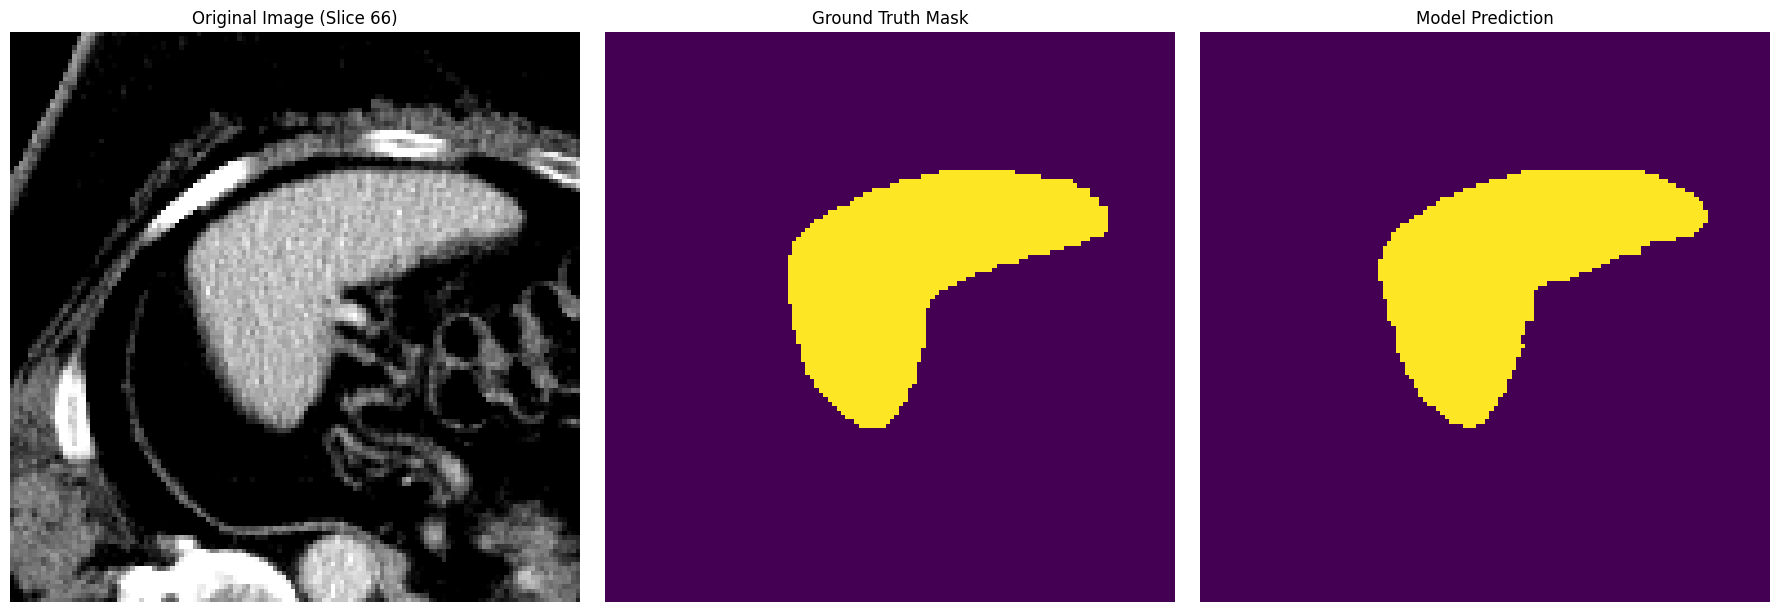

In [13]:
import torch
from monai.transforms import AsDiscrete

# Load the best saved model
model.load_state_dict(torch.load("best_metric_model.pth"))
model.eval()

# To convert model output to discrete binary mask
post_pred = AsDiscrete(argmax=True)
post_label = AsDiscrete(to_onehot=2)

with torch.no_grad():
    # Get a batch from the loader
    val_data = first(train_loader)
    val_inputs = val_data["image"].to(device)
    val_labels = val_data["label"].to(device)

    # Get prediction
    val_outputs = model(val_inputs)
    # Take the first image in the batch
    val_output_mask = post_pred(val_outputs[0]).cpu().numpy()[0] # Shape [H, W, D]
    val_true_mask = val_labels[0, 0].cpu().numpy() # Shape [H, W, D]
    val_img = val_inputs[0, 0].cpu().numpy()

# Find a slice that contains the spleen for visualization
slice_idx = np.argmax(np.sum(val_true_mask, axis=(0, 1)))

plt.figure("check", (18, 6))
plt.subplot(1, 3, 1)
plt.title(f"Original Image (Slice {slice_idx})")
plt.imshow(val_img[:, :, slice_idx], cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(val_true_mask[:, :, slice_idx])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(val_output_mask[:, :, slice_idx])
plt.axis('off')

plt.tight_layout()
plt.show()

### 7. Full-Volume Inference
We will now run the model on the full, uncropped image using a sliding window approach to visualize the segmentation across the entire scan.

Visualizing sample index: 11 - /tmp/tmp7c48tte3/Task09_Spleen/imagesTr/spleen_22.nii.gz


Loading dataset: 100%|██████████| 1/1 [00:03<00:00,  3.15s/it]


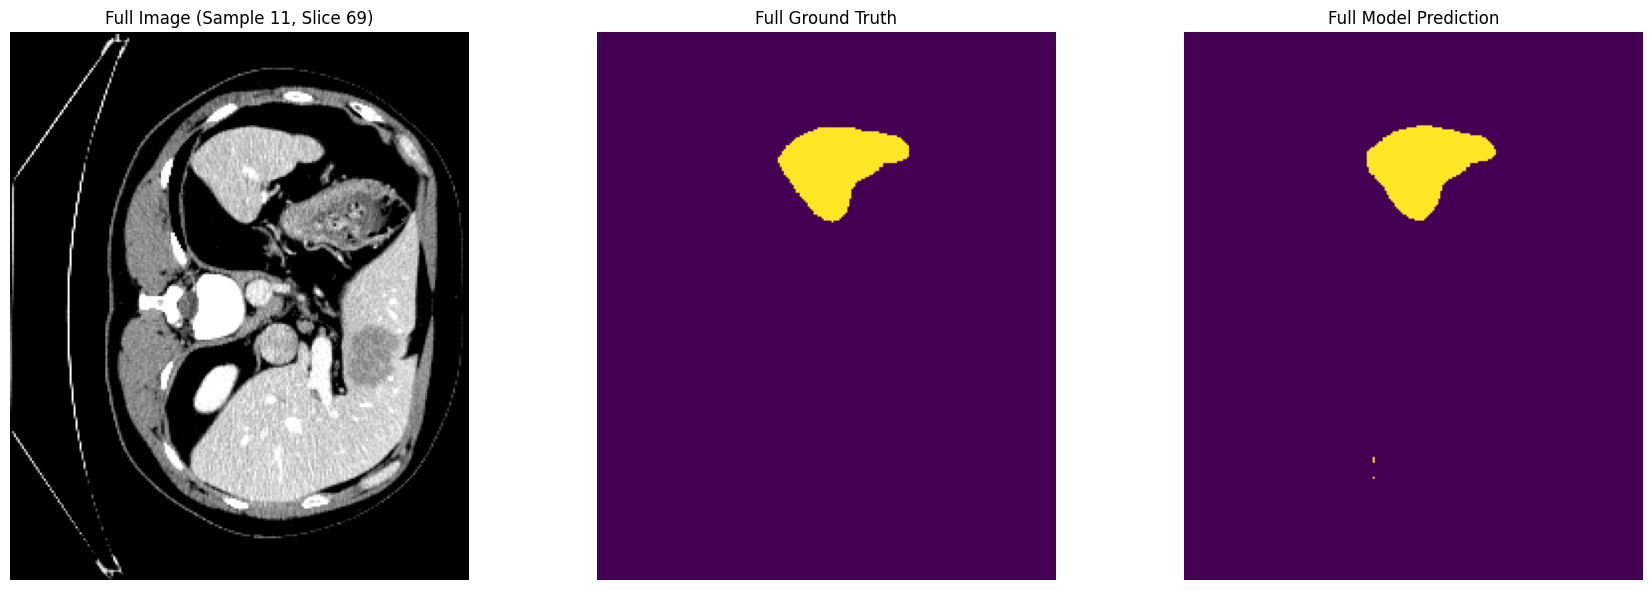

In [14]:
from monai.inferers import sliding_window_inference
import random

# Define the transforms for full-volume inference (no random cropping)
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
])

# Select a random sample from the dataset
random_idx = random.randint(0, len(data_dicts) - 1)
print(f"Visualizing sample index: {random_idx} - {data_dicts[random_idx]['image']}")

# Pick the random volume
val_ds = CacheDataset(data=data_dicts[random_idx:random_idx+1], transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1)

model.eval()
with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)

        # ROI size updated to match the new 128^3 training size
        roi_size = (128, 128, 128)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)

        # Convert to binary mask
        val_output_mask = torch.argmax(val_outputs, dim=1).detach().cpu()[0]
        val_image_full = val_inputs.cpu().numpy()[0, 0]
        val_label_full = val_labels.cpu().numpy()[0, 0]
        break

# Visualize a slice from the full volume (finding a slice with the label)
slice_idx = np.argmax(np.sum(val_label_full, axis=(0, 1)))

plt.figure("Full Volume Check", (18, 6))
plt.subplot(1, 3, 1)
plt.title(f"Full Image (Sample {random_idx}, Slice {slice_idx})")
plt.imshow(val_image_full[:, :, slice_idx], cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Full Ground Truth")
plt.imshow(val_label_full[:, :, slice_idx])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Full Model Prediction")
plt.imshow(val_output_mask[:, :, slice_idx])
plt.axis('off')

plt.tight_layout()
plt.show()

### 8. Post-Processing to Reduce False Positives
We will use `KeepLargestConnectedComponent` and `FillHoles` from MONAI to clean up the prediction by removing small noise clusters and ensuring a solid segmentation.

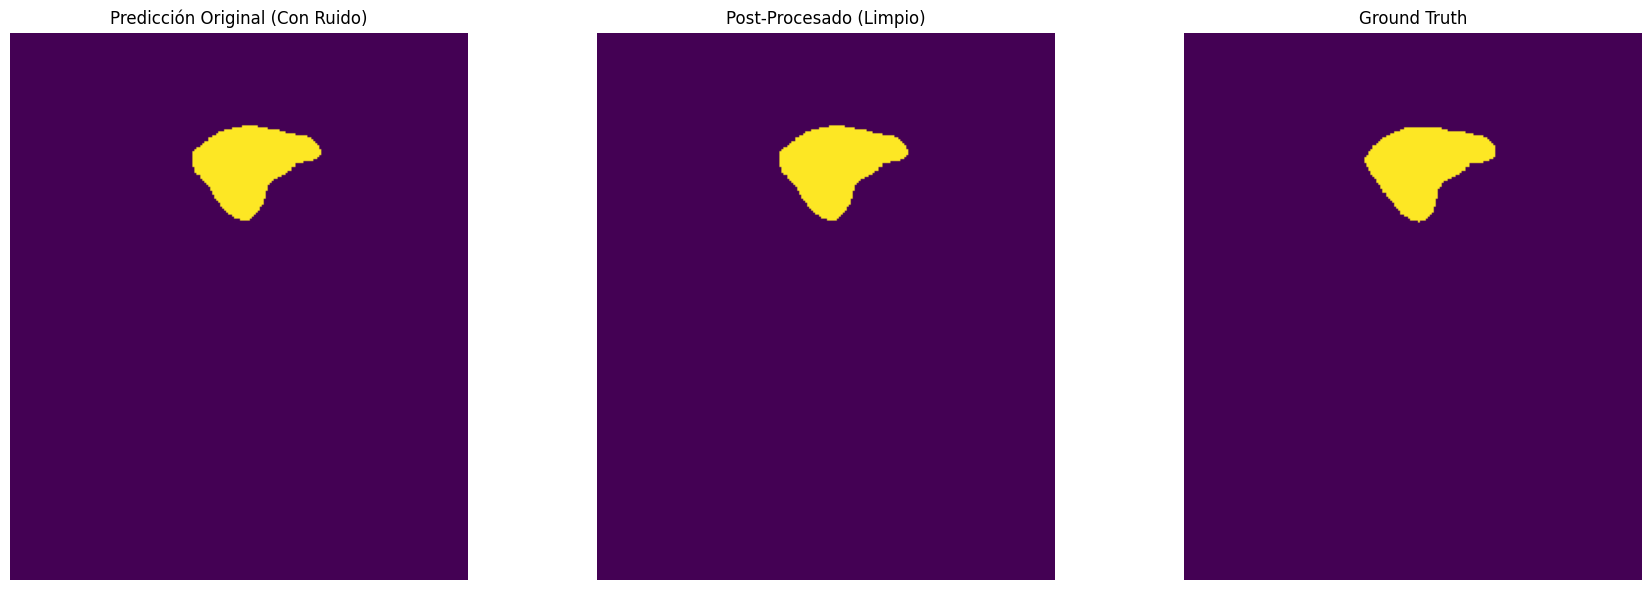

¡Post-procesado completado exitosamente usando NumPy 1.26.4!


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import KeepLargestConnectedComponent, FillHoles, Compose

# Esta cadena de transformaciones elimina falsos positivos pequeños y rellena huecos en la máscara
# Es compatible con NumPy 1.26.4
post_process = Compose([
    KeepLargestConnectedComponent(applied_labels=[1]),
    FillHoles(applied_labels=[1])
])

try:
    # Aplicamos el post-procesado a la salida de la inferencia
    # Convertimos a tensor con canal [C, H, W, D]
    processed_mask = post_process(val_output_mask.unsqueeze(0))[0].numpy()

    # Visualización de resultados
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(val_output_mask[:, :, slice_idx])
    axes[0].set_title("Predicción Original (Con Ruido)")
    axes[1].imshow(processed_mask[:, :, slice_idx])
    axes[1].set_title("Post-Procesado (Limpio)")
    axes[2].imshow(val_label_full[:, :, slice_idx])
    axes[2].set_title("Ground Truth")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"¡Post-procesado completado exitosamente usando NumPy {np.__version__}!")

except Exception as e:
    print(f"Error detectado: {e}")
    print("\nIMPORTANTE: Si ves un error de 'binary incompatibility', ve a 'Runtime' -> 'Restart session' y ejecuta todo de nuevo.")

### 9. Quantitative Evaluation (Mean Dice Score)
We will use the `DiceMetric` to calculate the average overlap between the prediction and the ground truth across a validation subset.

In [16]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete

# 1. Prepare Metric and Post-processing
dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(argmax=True, to_onehot=2)
post_label = AsDiscrete(to_onehot=2)

# 2. Setup Validation Loader
val_ds = CacheDataset(data=data_dicts[:10], transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1)

model.eval()
with torch.no_grad():
    for val_data in val_loader:
        val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)

        # Sliding window inference matched to 128^3
        roi_size = (128, 128, 128)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)

        # Convert outputs and labels to one-hot format
        val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
        val_labels = [post_label(i) for i in decollate_batch(val_labels)]

        # Compute metric
        dice_metric(y_pred=val_outputs, y=val_labels)

# 3. Aggregate and Print results
aggregate_dice = dice_metric.aggregate().item()
dice_metric.reset()

print(f"Mean Dice Score on Validation Set: {aggregate_dice:.4f}")

Loading dataset: 100%|██████████| 10/10 [00:23<00:00,  2.35s/it]


Mean Dice Score on Validation Set: 0.9066


### 10. Model Explainability with Grad-CAM
To make the model more transparent, we use Grad-CAM to visualize the regions of the 3D volume that most influenced the prediction of the spleen.

Generating Grad-CAM for validation sample index: 0
Grad-CAM Raw Min: 0.0, Max: 1.0


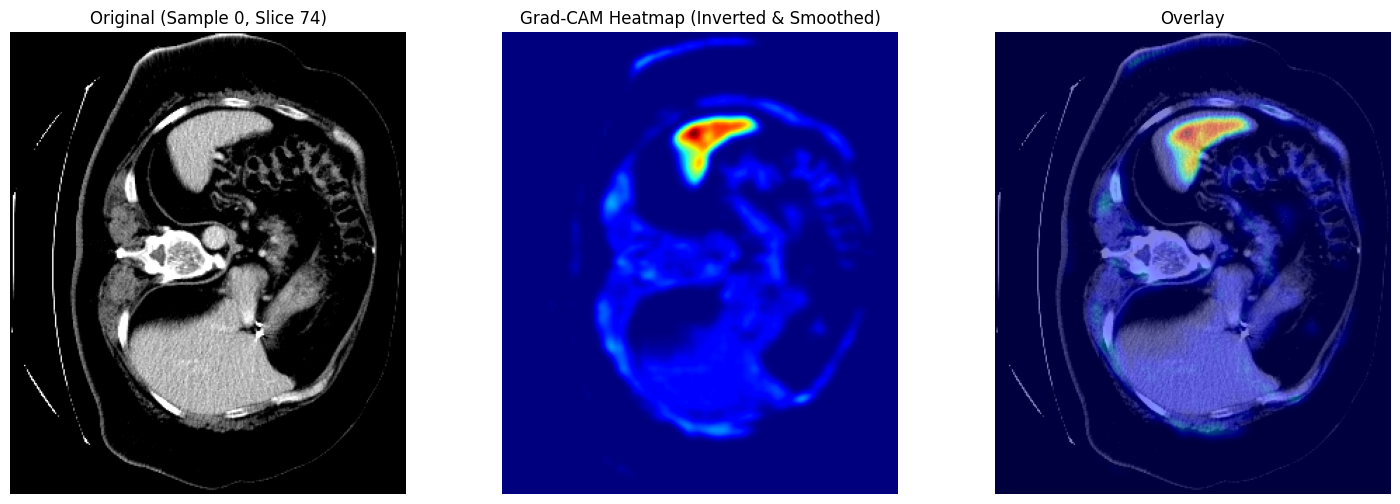

In [31]:
import random
import numpy as np
import matplotlib.pyplot as plt
from monai.visualize import GradCAM
from monai.transforms import DivisiblePad
from scipy.ndimage import gaussian_filter

# 1. Select a random sample from the validation data
random_val_idx = random.randint(0, len(val_ds) - 1)
print(f"Generating Grad-CAM for validation sample index: {random_val_idx}")
sample_data = val_ds[random_val_idx]
val_inputs = sample_data["image"][None].to(device) # Add batch dim
val_labels = sample_data["label"][None].to(device)

# 2. Initialize GradCAM with a shallower layer for broader activations
cam = GradCAM(nn_module=model, target_layers="model.1")

# 3. Ensure dimensions are divisible by 16 for the UNet skip connections
padder = DivisiblePad(k=16)
val_inputs_padded = padder(val_inputs[0])[None].to(device)

# 4. Compute Grad-CAM for the Spleen class (index 1)
result_cam = cam(x=val_inputs_padded, class_idx=1)

# 5. Crop the CAM back to original size
h, w, d = val_inputs.shape[2:]
result_cam = result_cam[0, 0, :h, :w, :d]

# --- Debugging & Normalization ---
cam_min, cam_max = result_cam.min().item(), result_cam.max().item()
print(f"Grad-CAM Raw Min: {cam_min}, Max: {cam_max}")

if cam_max > cam_min:
    # Normalize to [0, 1]
    result_cam = (result_cam - cam_min) / (cam_max - cam_min)
    # Move to CPU and convert to NumPy for SciPy operations
    result_cam = result_cam.cpu().numpy()
    # Apply Gaussian blur to smooth out disperse activations
    result_cam = gaussian_filter(result_cam, sigma=2.0)
    # Re-normalize after blurring
    result_cam = (result_cam - result_cam.min()) / (result_cam.max() - result_cam.min())

    # --- INVERT HEATMAP ---
    # Since shallow layers often highlight background, we invert the map
    # so the 'cold' isolated target becomes 'hot' (red)
    result_cam = 1.0 - result_cam
    # ----------------------
else:
    result_cam = result_cam.cpu().numpy()
    print("Warning: Grad-CAM min and max are equal. The layer might not be learning or the gradients are zero.")
# ---------------------------------

# 6. Find the best slice to visualize based on the Ground Truth
val_true_mask = val_labels[0, 0].cpu().numpy()
slice_idx = np.argmax(np.sum(val_true_mask, axis=(0, 1)))

# 7. Visualize
plt.figure("Grad-CAM", (18, 6))
plt.subplot(1, 3, 1)
plt.title(f"Original (Sample {random_val_idx}, Slice {slice_idx})")
plt.imshow(val_inputs[0, 0, :, :, slice_idx].cpu(), cmap="gray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap (Inverted & Smoothed)")
plt.imshow(result_cam[:, :, slice_idx], cmap="jet")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(val_inputs[0, 0, :, :, slice_idx].cpu(), cmap="gray")
plt.imshow(result_cam[:, :, slice_idx], cmap="jet", alpha=0.5)
plt.axis('off')
plt.show()
